In [2]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

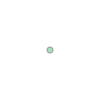

In [3]:
point = Point(0,0)
point

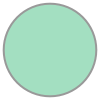

In [5]:
circle = Point(1,1).buffer(0.5)
circle

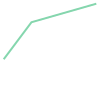

In [6]:
line = LineString([(2,2),(3.5,4),(7,5)])
line

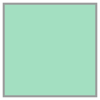

In [8]:
square = Polygon([(3,0),(3,1),(4,1),(4,0)])
square

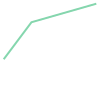

In [10]:
triangle = LineString([(2,2+1.5),(3.5,4+1.5),(7,5+1.5)])
triangle

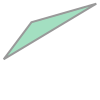

In [12]:
triangle = LineString([(2,2+1.5),(3.5,4+1.5),(7,5+1.5)]).convex_hull
triangle

### Creating a GeoDataFrame

In [14]:
geo_data  = {
    'point' : point,
    'circle' : circle,
    'line' : line,
    'square' : square,
    'triangle' : triangle
}
geo_data.keys()

dict_keys(['point', 'circle', 'line', 'square', 'triangle'])

In [16]:
geo_data.values()

dict_values([<POINT (0 0)>, <POLYGON ((1.5 1, 1.498 0.951, 1.49 0.902, 1.478 0.855, 1.462 0.809, 1.441 0...>, <LINESTRING (2 2, 3.5 4, 7 5)>, <POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))>, <POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))>])

In [17]:
import geopandas as gpd

In [19]:
gdf = gpd.GeoDataFrame(geo_data.items(),columns=['geo_name','geometry'])
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [20]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

### Simple functions and computations

In [21]:
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [24]:
gdf['geometry_type'] = gdf['geometry'].apply(lambda x: type(x).__name__)
gdf

,geo_name,geometry,geometry_type
0,point,POINT (0 0),Point
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon


In [26]:
gdf['geometry_buffered'] = gdf['geometry'].apply(lambda x: x.buffer(0.5))
gdf

,geo_name,geometry,geometry_type,geometry_buffered
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4...."
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0..."
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2...."


In [28]:
gdf['geometry_length'] = [g.length for g in gdf['geometry'].to_list()]
gdf['geometry_area'] = [g.area for g in gdf['geometry'].to_list()]

gdf

,geo_name,geometry,geometry_type,geometry_buffered,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


### Visualizing synthetic data with GeoPandas

In [30]:
import geopandas as gpd

In [31]:
gdf

,geo_name,geometry,geometry_type,geometry_buffered,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


<Axes: >

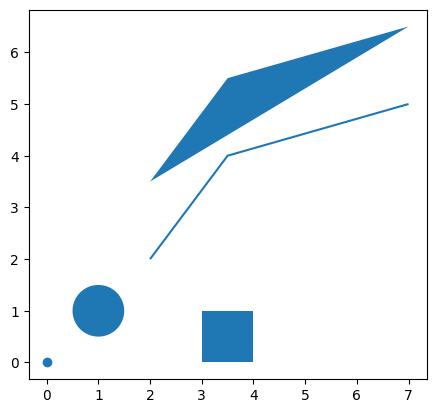

In [32]:
gdf.plot()

In [33]:
import matplotlib.pyplot as plt

<Axes: >

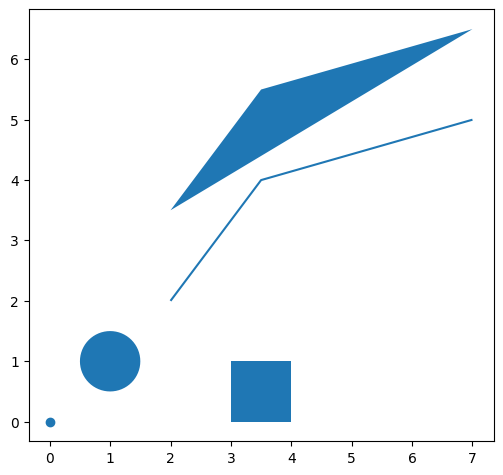

In [34]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax)

<Axes: >

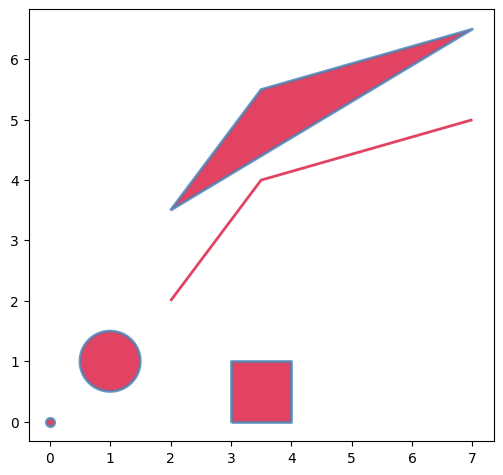

In [35]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
        color = 'crimson',
        edgecolor='steelblue',
        linewidth = 2,
        alpha = 0.8)

<Axes: >

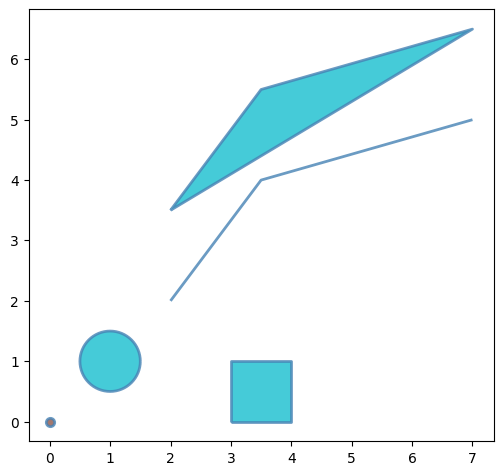

In [37]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
         column = 'geometry_type',
         edgecolor = 'steelblue',
         linewidth = 2,
         alpha = 0.8)

<Axes: >

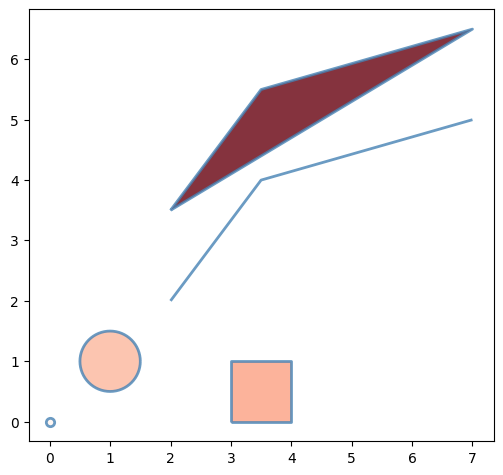

In [42]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
         column = 'geometry_length',
         cmap = 'Reds',
         edgecolor = 'steelblue',
         linewidth = 2,
         alpha = 0.8)

### Visualizing sample data with GeoPandas

In [46]:
import geopandas as gpd
from geodatasets import get_path

In [47]:
path = get_path('nybb')
gdf = gpd.read_file(path)
gdf

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [49]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'New York City map')

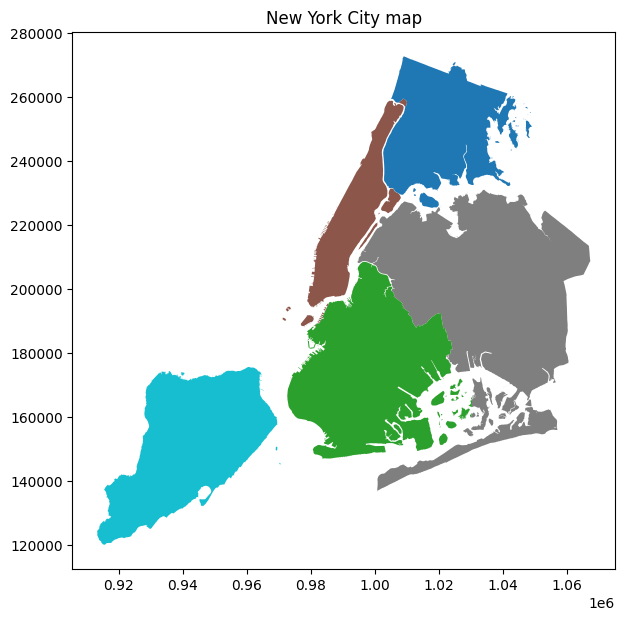

In [56]:
f, ax = plt.subplots(1,1,figsize = (7,7))

gdf.plot(ax = ax, column = 'BoroName', linewidth = 1.5, cmap = 'tab10')
ax.set_title('New York City map')

(905464.7390380859, 1075092.8783935546, 112485.76063504723, 280480.4142594267)


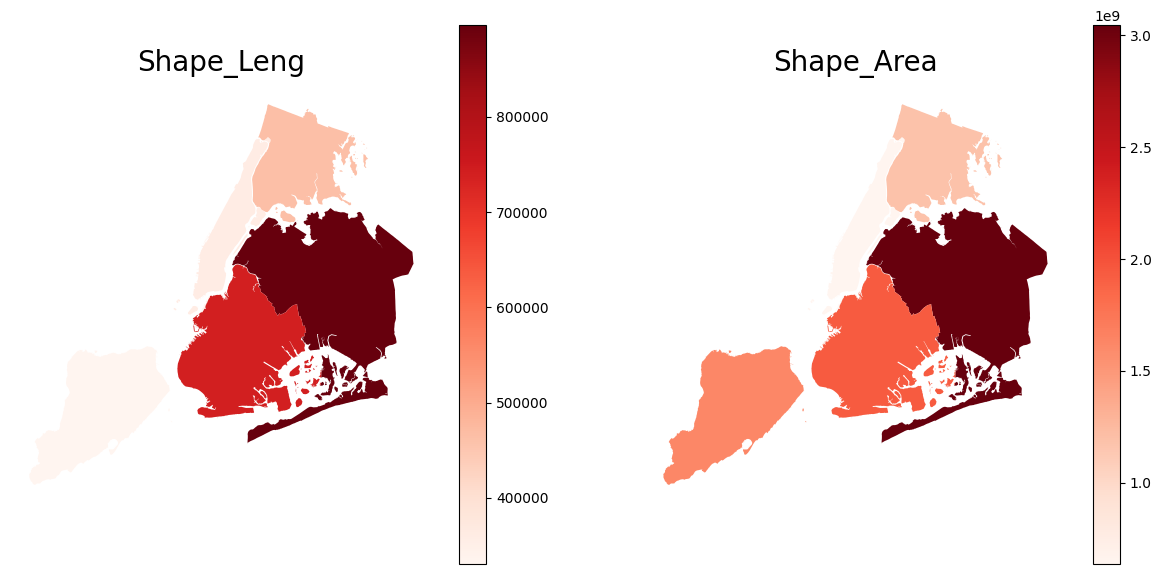

In [61]:
f, ax = plt.subplots(1,2,figsize=(15,7))

gdf.plot(column = 'Shape_Leng', ax = ax[0], cmap = 'Reds', legend = True)
gdf.plot(column = 'Shape_Area', ax = ax[1], cmap = 'Reds', legend = True)

ax[0].set_title('Shape_Leng', fontsize = 20, pad = 10)
ax[1].set_title('Shape_Area', fontsize = 20, pad = 10)

ax[0].axis('off')
ax[1].axis('off')

xlims = ax[0].get_xlim()
ylims = ax[0].get_ylim()

clean_lims = tuple(map(float, xlims + ylims))
print(clean_lims)

# Map projections

### Quering CRS

In [63]:
from geodatasets import get_path

In [87]:
path1 = get_path('nybb')
nybb = gpd.read_file(path1)
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [88]:
# Direct URL to Natural Earth countries shapefile (zipped)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

# Read directly from the URL
world = gpd.read_file(url)

In [89]:
# Quick plot
world.head(3)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."


In [91]:
print(nybb.crs)
print(world.crs)

EPSG:2263
EPSG:4326


In [92]:
nybb.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [96]:
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Global and local CRS 

In [97]:
world_nyc = world.to_crs('2263')

In [98]:
print(world_nyc.crs)

EPSG:2263


In [99]:
world_nyc.head(3)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-44383455.739 7369894.94, -446..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((39414397.961 10933271.416, 39488381...."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((20715700.071 3126064.149, 20732751.1..."


In [100]:
import matplotlib.pyplot as plt

<Axes: >

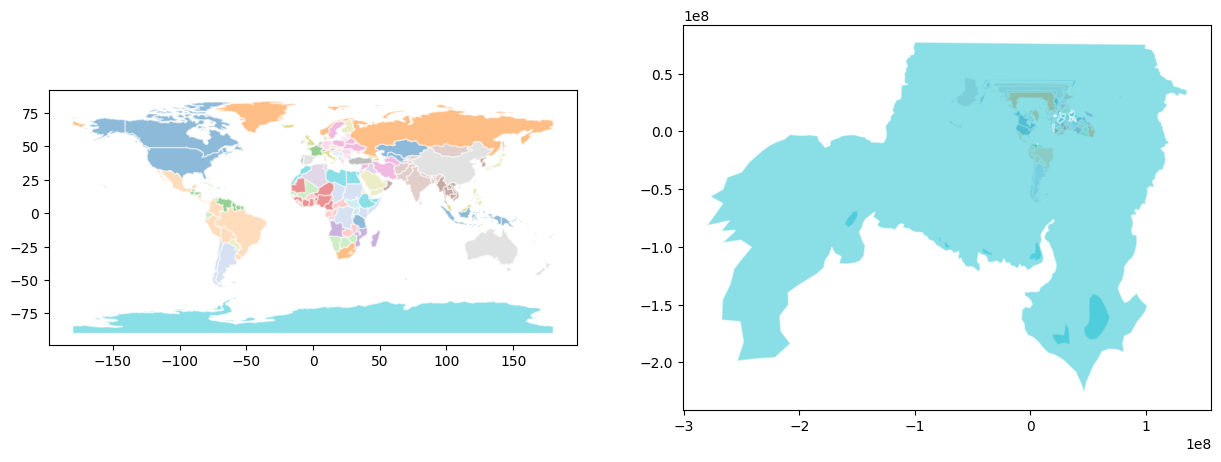

In [103]:
f, ax = plt.subplots(1,2,figsize=(15,7))

world.plot(ax=ax[0], edgecolor = 'w', cmap = 'tab20', alpha = 0.5, linewidth = 1)

world_nyc.plot(ax=ax[1], edgecolor = 'w', cmap = 'tab20', alpha = 0.5, linewidth = 1)

## TASK

In [106]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

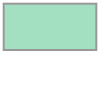

In [108]:
top = Polygon([(0,1),(0,2),(2,2),(2,1)])
bottom = Polygon([(-1,0),(-1,1),(4,1),(4,0)])
top

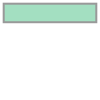

In [109]:
bottom

In [111]:
wheel_front = Point(0, -0,5).buffer(0.5)
wheel_rear = Point(3, -0,5).buffer(0.5)

In [112]:
geometries = [top,bottom,wheel_front,wheel_rear]
geometries

[<POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))>,
 <POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))>,
 <POLYGON ((0.5 0, 0.498 -0.049, 0.49 -0.098, 0.478 -0.145, 0.462 -0.191, 0.4...>,
 <POLYGON ((3.5 0, 3.498 -0.049, 3.49 -0.098, 3.478 -0.145, 3.462 -0.191, 3.4...>]

In [113]:
gdf = gpd.GeoDataFrame(geometry= geometries)
gdf.crs = 4326
display(gdf)

,geometry
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))"
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))"
2,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
3,"POLYGON ((3.5 0, 3.49759 -0.04901, 3.49039 -0...."


In [114]:
gdf['geometry_length'] = gdf.length
gdf['geometry_area'] = gdf.area

C:\Users\abres\AppData\Local\Temp\ipykernel_16084\2439555198.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_length'] = gdf.length
C:\Users\abres\AppData\Local\Temp\ipykernel_16084\2439555198.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_area'] = gdf.area


In [115]:
gdf.head()

,geometry,geometry_length,geometry_area
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))",6.000000,2.000000
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))",12.000000,5.000000
2,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",3.140331,0.784137
3,"POLYGON ((3.5 0, 3.49759 -0.04901, 3.49039 -0....",3.140331,0.784137


In [116]:
gdf['geometry'] = [g.buffer(0.2) for g in gdf.geometry.to_list()]
gdf.head()

,geometry,geometry_length,geometry_area
0,"POLYGON ((0 0.8, -0.0196 0.80096, -0.03902 0.8...",6.000000,2.000000
1,"POLYGON ((-1 -0.2, -1.0196 -0.19904, -1.03902 ...",12.000000,5.000000
2,"POLYGON ((0.69976 0.00981, 0.69976 -0.00981, 0...",3.140331,0.784137
3,"POLYGON ((3.69976 0.00981, 3.69976 -0.00981, 3...",3.140331,0.784137


<Axes: >

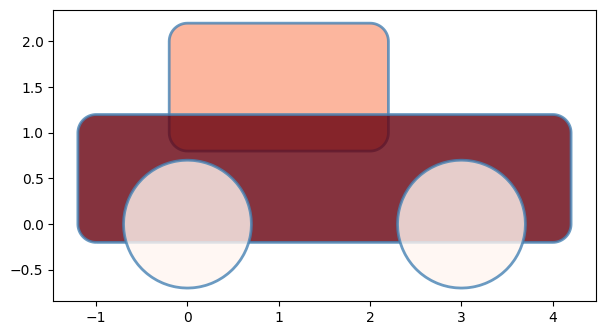

In [119]:
f, ax = plt.subplots(1,1, figsize=(7,7))

gdf.plot(column='geometry_length', ax=ax, cmap='Reds', edgecolor='steelblue', linewidth=2, alpha=0.8)

In [120]:
gdf_nyc = gdf.to_crs(2263)
gdf_hun = gdf.to_crs(23700)

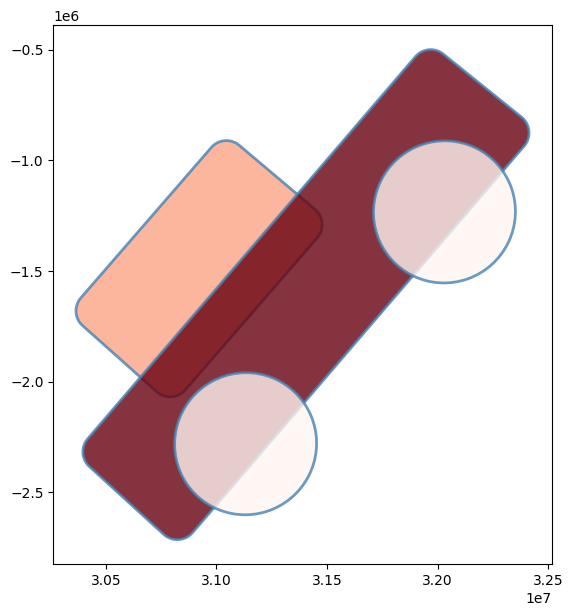

In [124]:
f,ax = plt.subplots(1,1, figsize=(7,7))
gdf_nyc.plot(column='geometry_length',ax=ax,cmap='Reds',edgecolor='steelblue',linewidth =2,alpha=0.8)
plt.show()

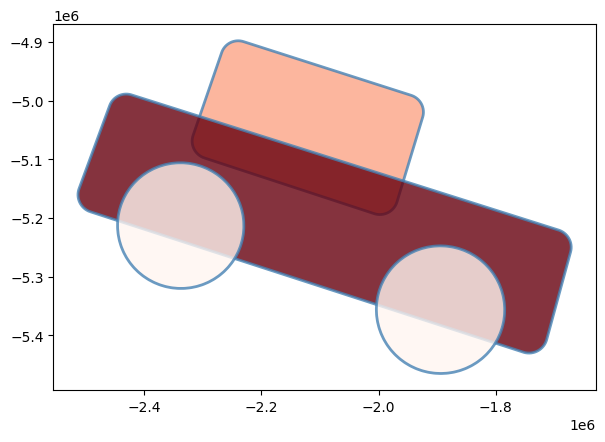

In [125]:
f,ax = plt.subplots(1,1, figsize=(7,7))
gdf_hun.plot(column='geometry_length',ax=ax,cmap='Reds',edgecolor='steelblue',linewidth =2,alpha=0.8)
plt.show()